In [1]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
import scipy
from PIL import Image
import pandas as pd
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.python.framework import ops

## The Sequential API

In [5]:
train_dataset = h5py.File('datasets/train_happy.h5', "r")
X_train_orig = np.array(train_dataset["train_set_x"][:]) 
Y_train_orig = np.array(train_dataset["train_set_y"][:]) 

test_dataset = h5py.File('datasets/test_happy.h5', "r")
X_test_orig = np.array(test_dataset["test_set_x"][:])
Y_test_orig = np.array(test_dataset["test_set_y"][:]) 

classes = np.array(test_dataset["list_classes"][:]) 

Y_train_orig = Y_train_orig.reshape((1, Y_train_orig.shape[0]))
Y_test_orig = Y_test_orig.reshape((1, Y_test_orig.shape[0]))

In [6]:
X_train = X_train_orig/255.
X_test = X_test_orig/255.

# Reshape
Y_train = Y_train_orig.T
Y_test = Y_test_orig.T

print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))

number of training examples = 600
number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600, 1)
X_test shape: (150, 64, 64, 3)
Y_test shape: (150, 1)


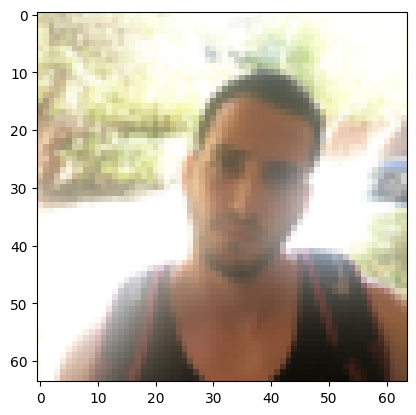

In [7]:
index = 85
plt.imshow(X_train_orig[index]) 
plt.show()

In [8]:
def happyModel():
    """
    Implements the forward propagation for the binary classification model:
    ZEROPAD2D -> CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> FLATTEN -> DENSE
    """
    model = tf.keras.Sequential([
            tfl.ZeroPadding2D(padding = (3, 3), input_shape = (64, 64, 3)),
            tfl.Conv2D(filters = 32, kernel_size = (7,7), strides = (1, 1)),
            tfl.BatchNormalization(axis=3),
            tfl.ReLU(),
            tfl.MaxPooling2D(),
            tfl.Flatten(),
            tfl.Dense(1, activation='sigmoid')
        ])
    
    return model

In [14]:
happy_model = happyModel()

In [15]:
happy_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

In [16]:
happy_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 zero_padding2d_3 (ZeroPaddi  (None, 70, 70, 3)        0         
 ng2D)                                                           
                                                                 
 conv2d_3 (Conv2D)           (None, 64, 64, 32)        4736      
                                                                 
 batch_normalization_3 (Batc  (None, 64, 64, 32)       128       
 hNormalization)                                                 
                                                                 
 re_lu_3 (ReLU)              (None, 64, 64, 32)        0         
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                      

In [17]:
happy_model.fit(X_train, Y_train, epochs=10, batch_size=16)

Epoch 1/10
38/38 [==============================] - 7s 8ms/step - loss: 1.5559 - accuracy: 0.6500
Epoch 2/10
38/38 [==============================] - 0s 3ms/step - loss: 0.2642 - accuracy: 0.8917
Epoch 3/10
38/38 [==============================] - 0s 3ms/step - loss: 0.3464 - accuracy: 0.8783
Epoch 4/10
38/38 [==============================] - 0s 3ms/step - loss: 0.2292 - accuracy: 0.9017
Epoch 5/10
38/38 [==============================] - 0s 3ms/step - loss: 0.1979 - accuracy: 0.9283
Epoch 6/10
38/38 [==============================] - 0s 3ms/step - loss: 0.1018 - accuracy: 0.9633
Epoch 7/10
38/38 [==============================] - 0s 3ms/step - loss: 0.0835 - accuracy: 0.9733
Epoch 8/10
38/38 [==============================] - 0s 3ms/step - loss: 0.0801 - accuracy: 0.9717
Epoch 9/10
38/38 [==============================] - 0s 3ms/step - loss: 0.0821 - accuracy: 0.9717
Epoch 10/10
38/38 [==============================] - 0s 3ms/step - loss: 0.0735 - accuracy: 0.9733


In [18]:
happy_model.evaluate(X_test, Y_test)

5/5 [==============================] - 0s 7ms/step - loss: 0.1700 - accuracy: 0.9267


[0.170000359416008, 0.9266666769981384]

## The Functional API

In [19]:
train_dataset = h5py.File('datasets/train_signs.h5', "r")
X_train_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
Y_train_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

test_dataset = h5py.File('datasets/test_signs.h5', "r")
X_test_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
Y_test_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

classes = np.array(test_dataset["list_classes"][:]) # the list of classes

Y_train_orig = Y_train_orig.reshape((1, Y_train_orig.shape[0]))
Y_test_orig = Y_test_orig.reshape((1, Y_test_orig.shape[0]))

y = 4


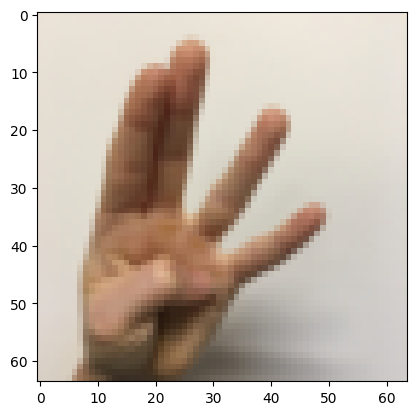

In [20]:
index = 9
plt.imshow(X_train_orig[index])
print ("y = " + str(np.squeeze(Y_train_orig[:, index])))

In [22]:
def convert_to_one_hot(Y, C):
    Y = np.eye(C)[Y.reshape(-1)].T
    return Y

X_train = X_train_orig/255.
X_test = X_test_orig/255.
Y_train = convert_to_one_hot(Y_train_orig, 6).T
Y_test = convert_to_one_hot(Y_test_orig, 6).T
print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))

number of training examples = 1080
number of test examples = 120
X_train shape: (1080, 64, 64, 3)
Y_train shape: (1080, 6)
X_test shape: (120, 64, 64, 3)
Y_test shape: (120, 6)


In [23]:
def convolutional_model(input_shape):
    """
    Implements the forward propagation for the model:
    CONV2D -> RELU -> MAXPOOL -> CONV2D -> RELU -> MAXPOOL -> FLATTEN -> DENSE
    """

    input_img = tf.keras.Input(shape=input_shape)
    
    Z1 = tfl.Conv2D(filters=8, kernel_size=(4,4), strides=(1,1), padding='same')(input_img)
    A1 = tfl.ReLU()(Z1)
    P1 = tfl.MaxPool2D(pool_size=(8,8), strides=8, padding='same')(A1)
    Z2 = tfl.Conv2D(filters=16, kernel_size=(2,2), strides=(1,1), padding='same')(P1)
    A2 = tfl.ReLU()(Z2)
    P2 = tfl.MaxPool2D(pool_size=(4,4), strides=4, padding='same')(A2)
    F = tfl.Flatten()(P2)
    outputs = tfl.Dense(6, activation='softmax')(F)

    model = tf.keras.Model(inputs=input_img, outputs=outputs)
    return model

In [24]:
conv_model = convolutional_model((64, 64, 3))
conv_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
conv_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 64, 64, 8)         392       
                                                                 
 re_lu_4 (ReLU)              (None, 64, 64, 8)         0         
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 8, 8, 8)          0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 8, 8, 16)          528       
                                                                 
 re_lu_5 (ReLU)              (None, 8, 8, 16)          0         
                                                             

In [25]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(64)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(64)
history = conv_model.fit(train_dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
17/17 [==============================] - 1s 15ms/step - loss: 1.7981 - accuracy: 0.1676 - val_loss: 1.7856 - val_accuracy: 0.1500
Epoch 2/100
17/17 [==============================] - 0s 6ms/step - loss: 1.7814 - accuracy: 0.2019 - val_loss: 1.7798 - val_accuracy: 0.2750
Epoch 3/100
17/17 [==============================] - 0s 6ms/step - loss: 1.7768 - accuracy: 0.2370 - val_loss: 1.7770 - val_accuracy: 0.2750
Epoch 4/100
17/17 [==============================] - 0s 6ms/step - loss: 1.7719 - accuracy: 0.2611 - val_loss: 1.7733 - val_accuracy: 0.2750
Epoch 5/100
17/17 [==============================] - 0s 6ms/step - loss: 1.7671 - accuracy: 0.2833 - val_loss: 1.7686 - val_accuracy: 0.3000
Epoch 6/100
17/17 [==============================] - 0s 6ms/step - loss: 1.7609 - accuracy: 0.2944 - val_loss: 1.7632 - val_accuracy: 0.3083
Epoch 7/100
17/17 [==============================] - 0s 6ms/step - loss: 1.7543 - accuracy: 0.3213 - val_loss: 1.7569 - val_accuracy: 0.3417
Epoch 8/100


C:\Users\mturk\AppData\Local\Temp\ipykernel_15208\973814028.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_loss.rename(columns={'loss':'train','val_loss':'validation'},inplace=True)
C:\Users\mturk\AppData\Local\Temp\ipykernel_15208\973814028.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_acc.rename(columns={'accuracy':'train','val_accuracy':'validation'},inplace=True)


[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Accuracy')]

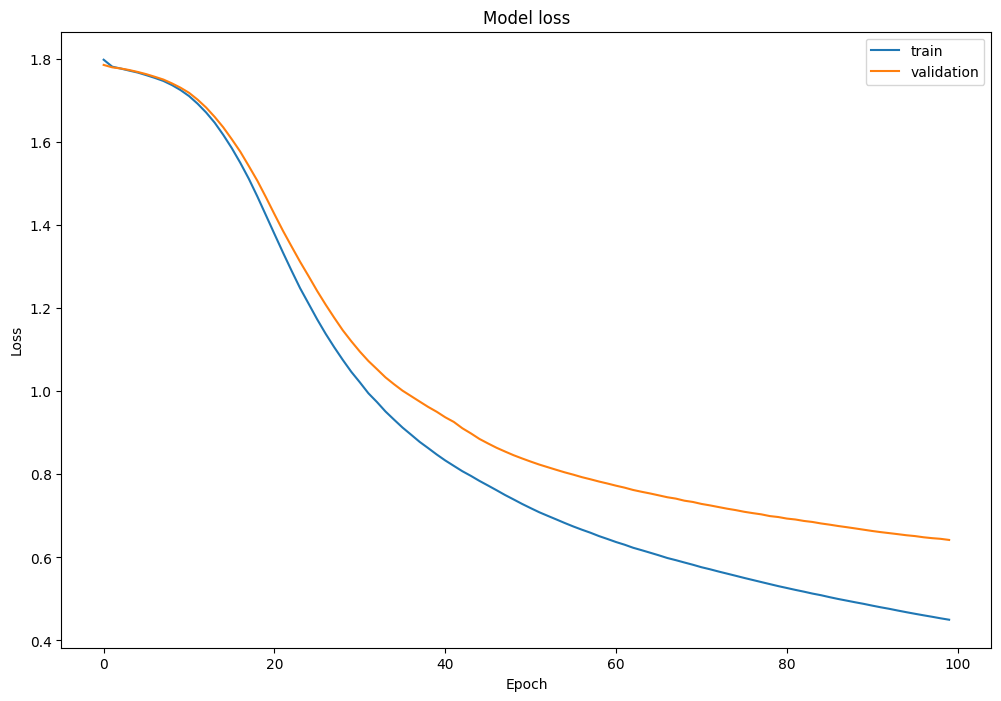

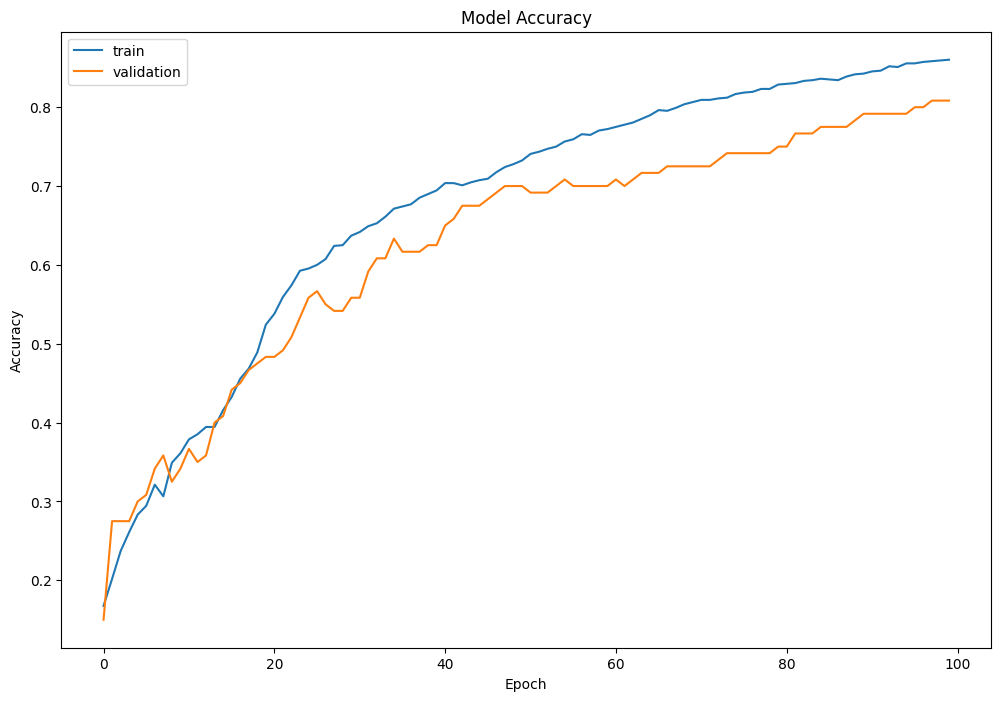

In [26]:
# The history.history["loss"] entry is a dictionary with as many values as epochs that the
# model was trained on. 
df_loss_acc = pd.DataFrame(history.history)
df_loss= df_loss_acc[['loss','val_loss']]
df_loss.rename(columns={'loss':'train','val_loss':'validation'},inplace=True)
df_acc= df_loss_acc[['accuracy','val_accuracy']]
df_acc.rename(columns={'accuracy':'train','val_accuracy':'validation'},inplace=True)
df_loss.plot(title='Model loss',figsize=(12,8)).set(xlabel='Epoch',ylabel='Loss')
df_acc.plot(title='Model Accuracy',figsize=(12,8)).set(xlabel='Epoch',ylabel='Accuracy')